In [2]:
import zipfile
import numpy as np
import pandas as pd
import time
from collections import Counter
import matplotlib.pyplot as plt

# =========================
# 1. Load dataset
# =========================
zip_path = "kmeans_data.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files in zip:", z.namelist())
    
    with z.open("data.csv") as f:
        X = pd.read_csv(f, header=None).values.astype(float)
    
    with z.open("label.csv") as f:
        y = pd.read_csv(f, header=None).values.ravel()

print("X shape:", X.shape)
print("y shape:", y.shape)

K = len(np.unique(y))
print("Number of classes (K):", K)

Files in zip: ['data_description.txt', 'data.csv', '__MACOSX/._data.csv', 'label.csv', '__MACOSX/._label.csv']
X shape: (10000, 784)
y shape: (10000,)
Number of classes (K): 10


In [3]:
# =========================
# 2. Distance functions
# =========================
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def cosine_distance(a, b):
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 1.0
    cosine_sim = np.dot(a, b) / (norm_a * norm_b)
    return 1 - cosine_sim

def generalized_jaccard_distance(a, b):
    # Generalized Jaccard for nonnegative vectors
    numerator = np.sum(np.minimum(a, b))
    denominator = np.sum(np.maximum(a, b))
    if denominator == 0:
        return 0.0
    return 1 - (numerator / denominator)

def compute_distance(a, b, metric):
    if metric == "euclidean":
        return euclidean_distance(a, b)
    elif metric == "cosine":
        return cosine_distance(a, b)
    elif metric == "jaccard":
        return generalized_jaccard_distance(a, b)
    else:
        raise ValueError("Unsupported metric")

In [4]:
# =========================
# 3. K-means from scratch
# =========================
def initialize_centroids(X, K, random_state=42):
    np.random.seed(random_state)
    indices = np.random.choice(X.shape[0], K, replace=False)
    return X[indices].copy()

def assign_clusters(X, centroids, metric):
    labels = []
    for x in X:
        distances = [compute_distance(x, c, metric) for c in centroids]
        labels.append(np.argmin(distances))
    return np.array(labels)

def update_centroids(X, labels, K):
    new_centroids = []
    for k in range(K):
        cluster_points = X[labels == k]
        if len(cluster_points) == 0:
            # reinitialize empty cluster centroid randomly
            new_centroids.append(X[np.random.randint(0, X.shape[0])])
        else:
            new_centroids.append(cluster_points.mean(axis=0))
    return np.array(new_centroids)

def compute_sse(X, labels, centroids, metric):
    sse = 0.0
    for i, x in enumerate(X):
        d = compute_distance(x, centroids[labels[i]], metric)
        sse += d ** 2
    return sse

def kmeans_from_scratch(X, K, metric="euclidean", max_iter=500, tol=1e-8,
                        stop_rule="combined", random_state=42):
    centroids = initialize_centroids(X, K, random_state=random_state)
    prev_sse = float("inf")
    start = time.time()
    stop_reason = None
    
    for it in range(1, max_iter + 1):
        labels = assign_clusters(X, centroids, metric)
        new_centroids = update_centroids(X, labels, K)
        current_sse = compute_sse(X, labels, new_centroids, metric)
        
        centroid_shift = np.linalg.norm(new_centroids - centroids)

        if stop_rule == "combined":
            if centroid_shift < tol:
                centroids = new_centroids
                stop_reason = "no centroid change"
                break
            if current_sse > prev_sse:
                stop_reason = "SSE increased"
                break
            if it == max_iter:
                centroids = new_centroids
                stop_reason = "max iteration reached"
                break

        elif stop_rule == "centroid":
            if centroid_shift < tol:
                centroids = new_centroids
                stop_reason = "no centroid change"
                break

        elif stop_rule == "sse":
            if current_sse > prev_sse:
                stop_reason = "SSE increased"
                break

        elif stop_rule == "max_iter":
            if it == max_iter:
                centroids = new_centroids
                stop_reason = "max iteration reached"
                break
        
        centroids = new_centroids
        prev_sse = current_sse

    elapsed = time.time() - start
    final_labels = assign_clusters(X, centroids, metric)
    final_sse = compute_sse(X, final_labels, centroids, metric)

    return {
        "labels": final_labels,
        "centroids": centroids,
        "sse": final_sse,
        "iterations": it,
        "time": elapsed,
        "stop_reason": stop_reason
    }

In [5]:
# =========================
# 4. Majority vote accuracy
# =========================
def majority_vote_mapping(cluster_labels, y_true, K):
    mapping = {}
    for k in range(K):
        true_labels = y_true[cluster_labels == k]
        if len(true_labels) == 0:
            mapping[k] = -1
        else:
            mapping[k] = Counter(true_labels).most_common(1)[0][0]
    return mapping

def predict_labels(cluster_labels, cluster_to_class):
    return np.array([cluster_to_class[c] for c in cluster_labels])

def clustering_accuracy(cluster_labels, y_true, K):
    mapping = majority_vote_mapping(cluster_labels, y_true, K)
    y_pred = predict_labels(cluster_labels, mapping)
    acc = np.mean(y_pred == y_true)
    return acc, mapping

In [6]:
# =========================
# 5. Q1, Q2, Q3
# =========================
metrics = ["euclidean", "cosine", "jaccard"]
results_q123 = []

for metric in metrics:
    result = kmeans_from_scratch(
        X, K,
        metric=metric,
        max_iter=500,
        stop_rule="combined",
        random_state=42
    )
    
    acc, mapping = clustering_accuracy(result["labels"], y, K)
    
    results_q123.append({
        "Metric": metric,
        "SSE": result["sse"],
        "Accuracy": acc,
        "Iterations": result["iterations"],
        "Time (sec)": result["time"],
        "Stop Reason": result["stop_reason"]
    })

q123_df = pd.DataFrame(results_q123)
print(q123_df)

      Metric           SSE  Accuracy  Iterations  Time (sec)  \
0  euclidean  2.541477e+10    0.5851          33   68.857308   
1     cosine  6.861891e+02    0.6264          28   71.392503   
2    jaccard  3.659784e+03    0.6012          34  103.748340   

          Stop Reason  
0  no centroid change  
1       SSE increased  
2       SSE increased  


In [7]:
# =========================
# 6. Q4
# =========================
stop_rules = {
    "No centroid change": "centroid",
    "SSE increases": "sse",
    "Max iterations = 100": "max_iter"
}

results_q4 = []

for metric in metrics:
    for stop_name, stop_rule in stop_rules.items():
        result = kmeans_from_scratch(
            X, K,
            metric=metric,
            max_iter=100,
            stop_rule=stop_rule,
            random_state=42
        )
        
        results_q4.append({
            "Metric": metric,
            "Stopping Condition": stop_name,
            "SSE": result["sse"],
            "Iterations": result["iterations"],
            "Time (sec)": result["time"]
        })

q4_df = pd.DataFrame(results_q4)
print(q4_df)

      Metric    Stopping Condition           SSE  Iterations  Time (sec)
0  euclidean    No centroid change  2.541477e+10          33   68.094532
1  euclidean         SSE increases  2.541477e+10         100  206.924844
2  euclidean  Max iterations = 100  2.541477e+10         100  206.441084
3     cosine    No centroid change  6.864356e+02          48  123.134922
4     cosine         SSE increases  6.861891e+02          28   71.649493
5     cosine  Max iterations = 100  6.864356e+02         100  251.523051
6    jaccard    No centroid change  3.660389e+03          59  179.471538
7    jaccard         SSE increases  3.659784e+03          34  106.928264
8    jaccard  Max iterations = 100  3.660389e+03         100  302.731802


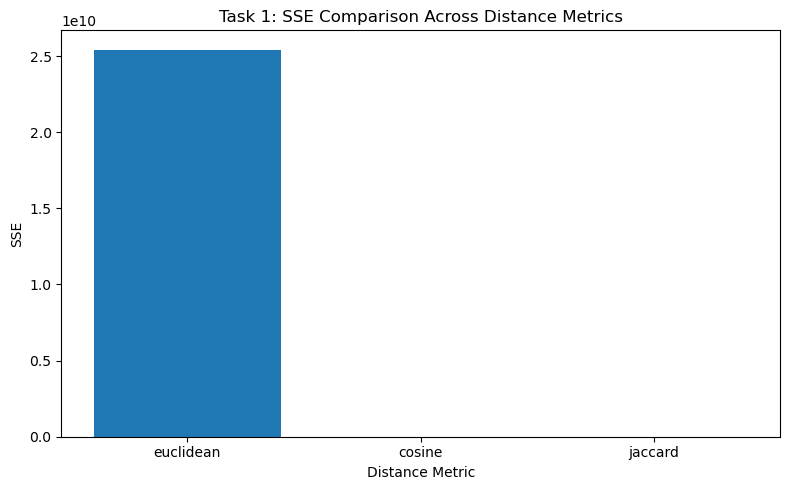

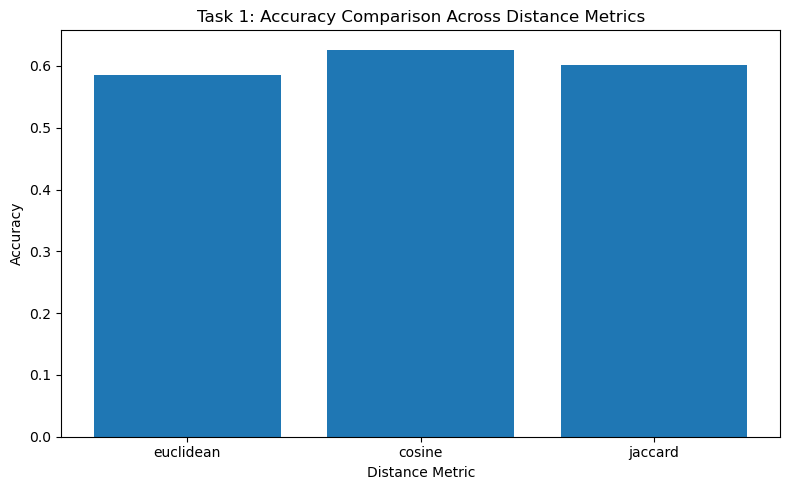

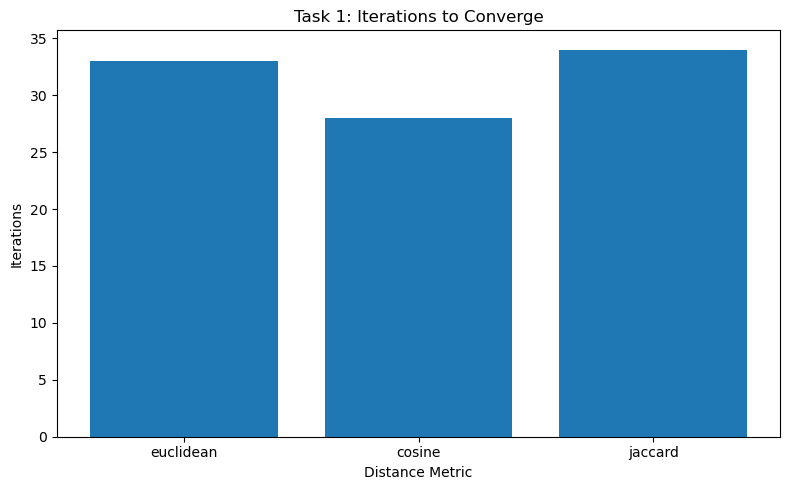

In [9]:
# =========================
# 7. Plots
# =========================

# Q1 SSE comparison
plt.figure(figsize=(8,5))
plt.bar(q123_df["Metric"], q123_df["SSE"])
plt.title("Task 1: SSE Comparison Across Distance Metrics")
plt.xlabel("Distance Metric")
plt.ylabel("SSE")
plt.tight_layout()
plt.savefig("task1_sse.png", dpi=300, bbox_inches="tight")
plt.show()

# Q2 Accuracy comparison
plt.figure(figsize=(8,5))
plt.bar(q123_df["Metric"], q123_df["Accuracy"])
plt.title("Task 1: Accuracy Comparison Across Distance Metrics")
plt.xlabel("Distance Metric")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("task1_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# Q3 Iteration comparison
plt.figure(figsize=(8,5))
plt.bar(q123_df["Metric"], q123_df["Iterations"])
plt.title("Task 1: Iterations to Converge")
plt.xlabel("Distance Metric")
plt.ylabel("Iterations")
plt.tight_layout()
plt.savefig("task1_iterations.png", dpi=300, bbox_inches="tight")
plt.show()